<a href="https://colab.research.google.com/github/mehmeterkann/TMDB-Movie-Dataset-Analysis/blob/main/TMDB_Movie_Dataset_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# TMDB Movie Dataset Analysis

This project analyzes 1.4 million movies from the TMDB dataset.

**Questions explored:**
1. Which genres generate the highest revenue?
2. Does higher budget lead to higher revenue?
3. How has film production changed over the years?
4. Which genres are most popular?
5. Which languages produce the most popular films?

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
import matplotlib.pyplot as plt


In [3]:
data=pd.read_csv("/content/drive/MyDrive/TMDB_movie_dataset_v11.csv")


In [4]:
print(data.head())
print(data.shape)
print(data.info)
print(data.isnull().sum())

       id            title  vote_average  vote_count    status release_date  \
0   27205        Inception         8.364       34495  Released   2010-07-15   
1  157336     Interstellar         8.417       32571  Released   2014-11-05   
2     155  The Dark Knight         8.512       30619  Released   2008-07-16   
3   19995           Avatar         7.573       29815  Released   2009-12-15   
4   24428     The Avengers         7.710       29166  Released   2012-04-25   

      revenue  runtime  adult                     backdrop_path  ...  \
0   825532764      148  False  /8ZTVqvKDQ8emSGUEMjsS4yHAwrp.jpg  ...   
1   701729206      169  False  /pbrkL804c8yAv3zBZR4QPEafpAR.jpg  ...   
2  1004558444      152  False  /nMKdUUepR0i5zn0y1T4CsSB5chy.jpg  ...   
3  2923706026      162  False  /vL5LR6WdxWPjLPFRLe133jXWsh5.jpg  ...   
4  1518815515      143  False  /9BBTo63ANSmhC4e6r62OJFuK2GL.jpg  ...   

    original_title                                           overview  \
0        Inception 

In [5]:
data.drop(columns=["backdrop_path","homepage","poster_path","tagline",
                   "imdb_id","keywords","production_companies",
                   "production_countries","spoken_languages",], inplace=True)

data.dropna(subset=["genres","release_date","title"], inplace=True)

data["release_date"]=pd.to_datetime(data["release_date"])
data["release_year"]=data["release_date"].dt.year
data["genres"]=data["genres"].str.strip()
data["genres"] = data["genres"].str.split(", ")

data_exploded=data.explode("genres")
data_exploded["genres"]=data_exploded["genres"].str.strip()

In [6]:
genre_revenue = data_exploded.groupby("genres")["revenue"].mean().sort_values(ascending=False)

filtered = data[(data["budget"]>0) & (data["revenue"]>0)]

popular=data_exploded.groupby("genres")["popularity"].mean().sort_values(ascending=False)

print(popular.round(2))

genres
Adventure          4.50
Action             4.01
Thriller           3.67
Science Fiction    3.56
Fantasy            3.15
Mystery            2.93
Crime              2.85
Family             2.83
Romance            2.54
War                2.43
Horror             2.25
History            2.03
Western            1.97
Comedy             1.96
TV Movie           1.84
Drama              1.80
Animation          1.61
Music              1.01
Documentary        0.75
Name: popularity, dtype: float64


In [7]:
language=data.groupby("original_language")["popularity"].agg(["mean","count"])
language=language[(language["count"]>=50)]["mean"].sort_values(ascending=False).head(10)
print(language)

original_language
cn    2.926208
ko    2.755201
hi    2.071981
ja    1.951753
en    1.902629
it    1.860486
is    1.823886
te    1.729738
ta    1.613968
ml    1.387731
Name: mean, dtype: float64


In [8]:
correlation=filtered["budget"].corr(filtered["revenue"])




data = data[(data["release_year"]>1900)& (data["release_year"]<2026)]


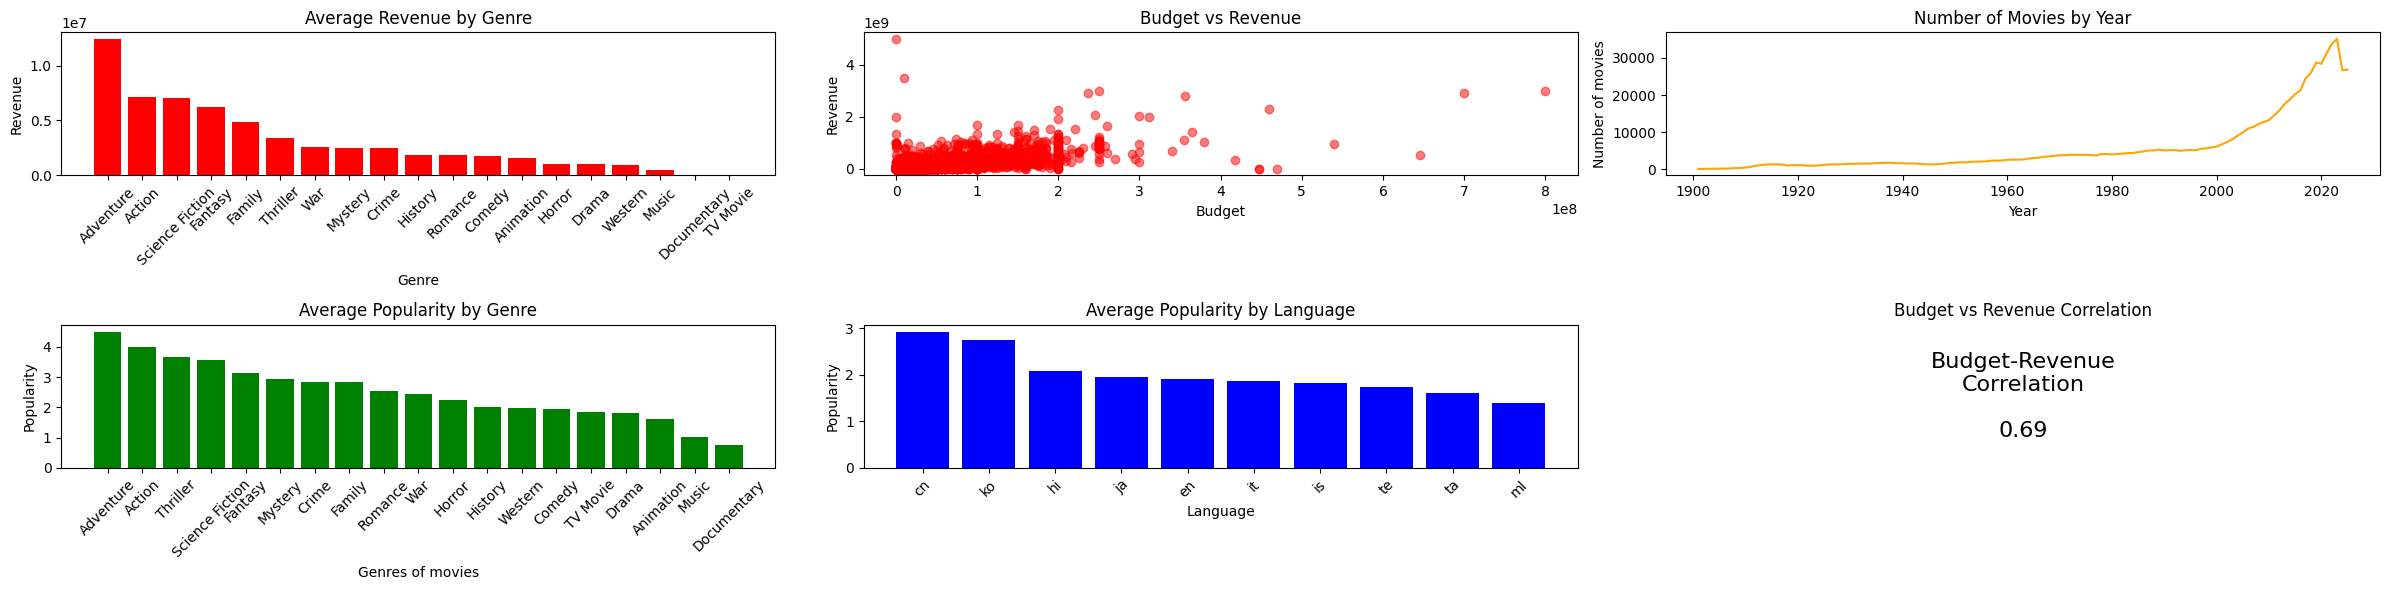

In [9]:
fig, ax= plt.subplots(2,3,figsize=(24,6))
ax[0][0].bar(genre_revenue.index,genre_revenue,color="red")
ax[0][0].set_xlabel("Genre")
ax[0][0].set_ylabel("Revenue")
ax[0][0].tick_params(axis="x", rotation=45)
ax[0][0].set_title("Average Revenue by Genre")

ax[0][1].scatter(filtered["budget"],filtered["revenue"],color="red",alpha=0.5)
ax[0][1].set_xlabel("Budget")
ax[0][1].set_ylabel("Revenue")
ax[0][1].set_title("Budget vs Revenue")
counts=data.groupby("release_year")["genres"].count()

ax[0][2].plot(counts.index,counts,color="orange")
ax[0][2].set_xlabel("Year")
ax[0][2].set_ylabel("Number of movies")
ax[0][2].set_title("Number of Movies by Year")

ax[1][0].bar(popular.index,popular,color="green")
ax[1][0].set_xlabel("Genres of movies")
ax[1][0].set_ylabel("Popularity")
ax[1][0].tick_params(axis="x", rotation=45)
ax[1][0].set_title("Average Popularity by Genre")

ax[1][1].bar(language.index,language,color="blue")
ax[1][1].set_xlabel("Language")
ax[1][1].set_ylabel("Popularity")
ax[1][1].tick_params(axis="x", rotation=45)
ax[1][1].set_title("Average Popularity by Language")

ax[1][2].text(0.5, 0.5, f'Budget-Revenue\nCorrelation\n\n{correlation:.2f}',
              ha='center', va='center', fontsize=16, transform=ax[1][2].transAxes)
ax[1][2].set_title("Budget vs Revenue Correlation")
ax[1][2].axis('off')


plt.tight_layout()
plt.show()

## 1. Average Revenue by Genre
Adventure and Action films generate the highest average revenue.

## 2. Budget vs Revenue
Higher budget films tend to generate more revenue (correlation: 0.69).

## 3. Number of Movies by Year
Film production increased dramatically after 2000.

## 4. Average Popularity by Genre
Adventure and Action are the most popular genres.

## 5. Average Popularity by Language
Chinese and Korean films have the highest average popularity.